# Regression using Artificial Neural Networks

using the droped feature data set


In [2]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import tensorflow as tf
import matplotlib.pyplot as plt


pd.set_option('display.float_format', '{:.4f}'.format)

sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

imports ok


##Load Data

In [3]:
# Load data file
data = pd.read_csv('C:\\Users\\DD\\Desktop\\IAAC\\DATA encoding\\final project_entropy prediction\\data\\processed\\dataset_dropped_features_clean.csv')
pd.options.display.max_columns = None

print(data)

             patch_id   city_code  entropy_normalised  n_3way  n_deadend  \
0        chicago_0338     chicago              0.4445     109          7   
1     chandigarh_0157  chandigarh              0.4290     141          5   
2        chicago_0085     chicago              0.3901      72          0   
3        chicago_0637     chicago              0.4223     115          8   
4        chicago_0582     chicago              0.3950     111          3   
...               ...         ...                 ...     ...        ...   
2495       leeds_0304       leeds              0.9459     112         49   
2496      munich_0137      munich              0.9715      80         12   
2497     telaviv_0100     telaviv              0.9543     163         15   
2498    istanbul_3066    istanbul              0.9733     106          9   
2499  bratislava_0103  bratislava              0.9511      59         15   

      proportion_4way  proportion_3way  proportion_deadend  mean_edge_length  \
0      

In [4]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patch_id            2500 non-null   str    
 1   city_code           2500 non-null   str    
 2   entropy_normalised  2500 non-null   float64
 3   n_3way              2500 non-null   int64  
 4   n_deadend           2500 non-null   int64  
 5   proportion_4way     2500 non-null   float64
 6   proportion_3way     2500 non-null   float64
 7   proportion_deadend  2500 non-null   float64
 8   mean_edge_length    2500 non-null   float64
 9   total_edge_length   2500 non-null   float64
 10  circuity            2500 non-null   float64
dtypes: float64(7), int64(2), str(2)
memory usage: 215.0 KB
None


In [5]:
for colname, col in data.items():
  print(colname, "min_val", col.min(), "max_val", col.max())

patch_id min_val adelaide_0020 max_val warsaw_0808
city_code min_val adelaide max_val warsaw
entropy_normalised min_val 0.383996 max_val 0.992793
n_3way min_val 9 max_val 881
n_deadend min_val 0 max_val 449
proportion_4way min_val 0.0 max_val 0.747922
proportion_3way min_val 0.115385 max_val 0.916667
proportion_deadend min_val 0.0 max_val 0.557692
mean_edge_length min_val 16.86 max_val 165.62
total_edge_length min_val 701.87 max_val 39750.52
circuity min_val 0.998254 max_val 1.445991


In [6]:
data.describe()

,entropy_normalised,n_3way,n_deadend,proportion_4way,proportion_3way,proportion_deadend,mean_edge_length,total_edge_length,circuity
count,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000
mean,0.6921,105.0856,34.4676,0.2156,0.4949,0.1785,56.6371,14225.2829,1.0494
std,0.1737,85.6122,37.0734,0.1777,0.1171,0.1077,20.8052,7873.8953,0.0500
min,0.3840,9.0000,0.0000,0.0000,0.1154,0.0000,16.8600,701.8700,0.9983
25%,0.5414,47.0000,12.0000,0.0833,0.4231,0.0949,40.5900,8223.5825,1.0164
50%,0.6901,86.0000,23.0000,0.1634,0.5000,0.1667,52.0350,12638.5000,1.0366
75%,0.8471,137.0000,43.2500,0.2926,0.5735,0.2500,67.6125,19096.2925,1.0640
max,0.9928,881.0000,449.0000,0.7479,0.9167,0.5577,165.6200,39750.5200,1.4460


In [7]:
print(data.columns.tolist())


['patch_id', 'city_code', 'entropy_normalised', 'n_3way', 'n_deadend', 'proportion_4way', 'proportion_3way', 'proportion_deadend', 'mean_edge_length', 'total_edge_length', 'circuity']


we can see that some predictors are binary, while others are not

In [8]:
feature_cols = ['n_3way', 'n_deadend', 'proportion_4way', 'proportion_3way',
                'proportion_deadend', 'mean_edge_length', 'total_edge_length', 'circuity']

print("Features:", feature_cols)
print("Target: entropy_normalised")
data[feature_cols].describe()


Features: ['n_3way', 'n_deadend', 'proportion_4way', 'proportion_3way', 'proportion_deadend', 'mean_edge_length', 'total_edge_length', 'circuity']
Target: entropy_normalised


,n_3way,n_deadend,proportion_4way,proportion_3way,proportion_deadend,mean_edge_length,total_edge_length,circuity
count,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000
mean,105.0856,34.4676,0.2156,0.4949,0.1785,56.6371,14225.2829,1.0494
std,85.6122,37.0734,0.1777,0.1171,0.1077,20.8052,7873.8953,0.0500
min,9.0000,0.0000,0.0000,0.1154,0.0000,16.8600,701.8700,0.9983
25%,47.0000,12.0000,0.0833,0.4231,0.0949,40.5900,8223.5825,1.0164
50%,86.0000,23.0000,0.1634,0.5000,0.1667,52.0350,12638.5000,1.0366
75%,137.0000,43.2500,0.2926,0.5735,0.2500,67.6125,19096.2925,1.0640
max,881.0000,449.0000,0.7479,0.9167,0.5577,165.6200,39750.5200,1.4460


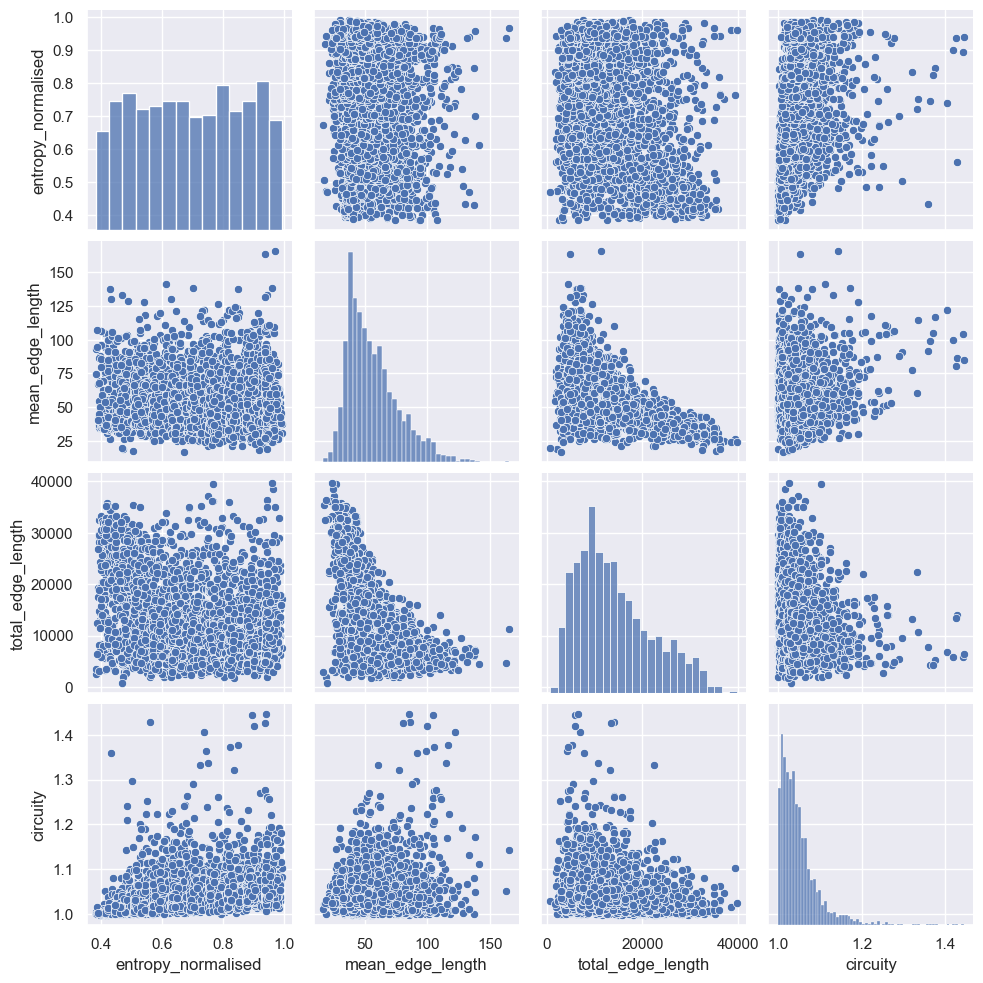

In [9]:
data_numerical = data[['entropy_normalised', 'mean_edge_length', 'total_edge_length', 'circuity']]
sns.pairplot(data_numerical)


We can see there is a direct relationship between age and experience, but not so much between wage and education, there is a non-linearity

##Prepare Data

**NORMALIZE INPUTS**

In [10]:
#same code as last time

feature_cols = ['n_3way', 'n_deadend', 'proportion_4way', 'proportion_3way',
                'proportion_deadend', 'mean_edge_length', 'total_edge_length', 'circuity']

X = data[feature_cols].to_numpy()

from sklearn.preprocessing import StandardScaler
scalerX = StandardScaler()

X_scaled = scalerX.fit_transform(X)

print(X_scaled.shape)


(2500, 8)


In [11]:
#declare regression target
y = data.loc[:, "entropy_normalised"].to_numpy()

y = y.reshape(-1, 1)

from sklearn.preprocessing import MinMaxScaler
scalerY = MinMaxScaler()

# Apply the scaler to our Y-features
y_scaled = scalerY.fit_transform(y)

print(y_scaled.shape)



(2500, 1)


**SPLIT INTO TRAIN AND TEST**

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size = 0.2, random_state = 21)

In [13]:
#visualize our data
#we can see that scikitlearn doesnt care if it is a dataframe or a numpy array, because they all function on the same way
print("TRAIN", "input", X_train.shape, "output", y_train.shape)
print("TEST", "input", X_test.shape, "output", y_test.shape)


TRAIN input (2000, 8) output (2000, 1)
TEST input (500, 8) output (500, 1)


#Build model

From the cheatSheet
Regression between 0 and 1>>
      activation = relu for hidden layers / sigmoid for final layer
      loss = mean squared error
      optimizer = adam
      input from data, is 8 columns
      output is 1 value prediction

In [14]:
# Instantiate a sequential model
model = tf.keras.models.Sequential()
n_cols = X_scaled.shape[1]

model.add(tf.keras.layers.Input(shape=(n_cols,)))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='linear'))  # <-- key change

model.compile(optimizer='adam', loss='mean_squared_error')




In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

#Train model

In [16]:
# Fit your model to the training data for 200 epochs
#we assign this to history variable so we can plot the training data
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=500, validation_split=0.2, callbacks=[early_stop])


Epoch 1/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2407 - val_loss: 0.0885
Epoch 2/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1028 - val_loss: 0.0708
Epoch 3/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0867 - val_loss: 0.0634
Epoch 4/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0810 - val_loss: 0.0576
Epoch 5/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0704 - val_loss: 0.0548
Epoch 6/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0668 - val_loss: 0.0530
Epoch 7/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0623 - val_loss: 0.0501
Epoch 8/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0581 - val_loss: 0.0485
Epoch 9/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0553 - val_loss: 0.0477
Epoch 10/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0545 - val_loss: 0.0478
Epoch 11/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0517 - val_loss: 0.0453
Epoch 12/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0

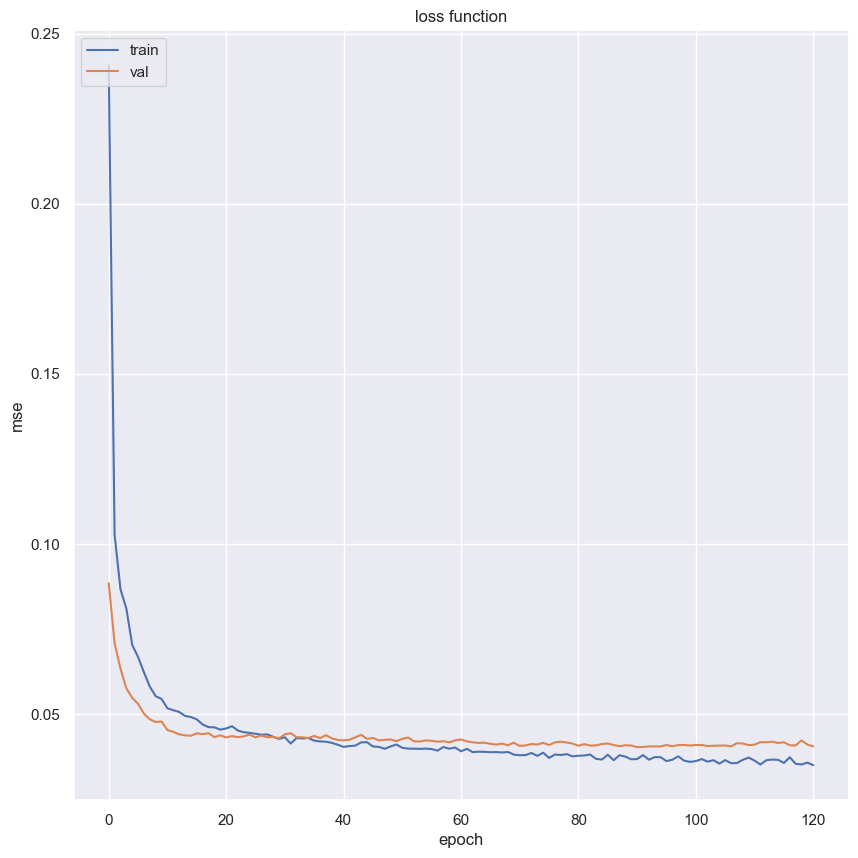

In [17]:
# summarize history for accuracy
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss function')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

#Evaluate model on test data



In [18]:
# Evaluate your model accuracy on the test data
loss_test = model.evaluate(X_test,y_test)

# Print accuracy
print('mse_test:', loss_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0399 
mse_test: 0.039865974336862564


#Plot error


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Text(0, 0.5, 'y_pred (entropy normalised)')

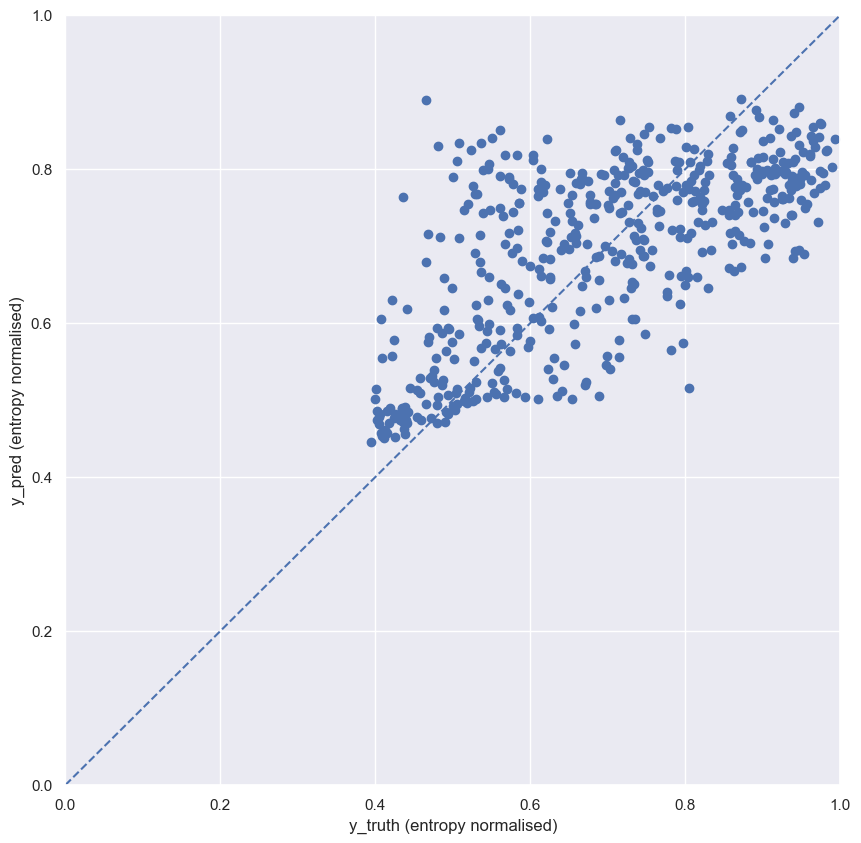

In [19]:
y_pred = scalerY.inverse_transform(model.predict(X_test))
y_truth = scalerY.inverse_transform(y_test)

plt.scatter(y_truth, y_pred)
plt.ylim((0, 1))
plt.xlim((0, 1))
plt.axline((0, 0), slope=1, ls="--")

plt.xlabel("y_truth (entropy normalised)")
plt.ylabel("y_pred (entropy normalised)")



In [20]:
def plot_comparison(x_val, pred, truth, xlab, ylab):
  fig, ax1 = plt.subplots(figsize = (10,10))
  ax1.plot(x_val, truth, color = "red", label = "truth",linestyle='None', marker = "o", markersize = 5)
  ax1.plot(x_val, pred, color = "blue", label = "pred",linestyle='None', marker = "o", markersize = 4, alpha = 0.5)

  ax1.set_xlabel(xlab)
  ax1.set_ylabel(ylab)
  ax1.legend()
  plt.title('Prediction Comparison')
  plt.show()

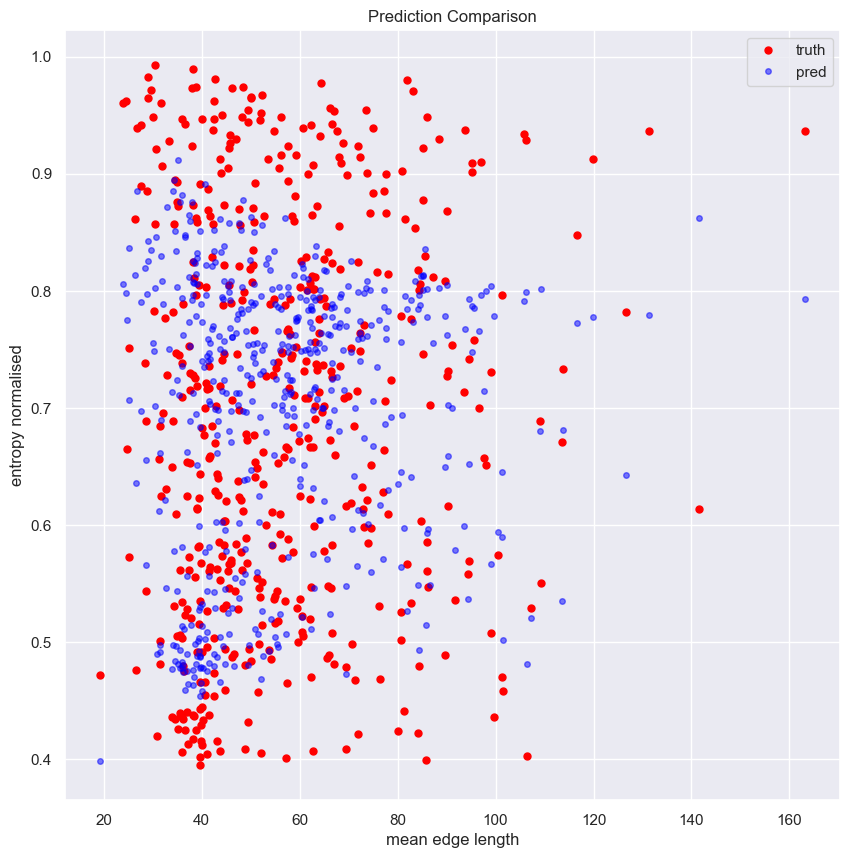

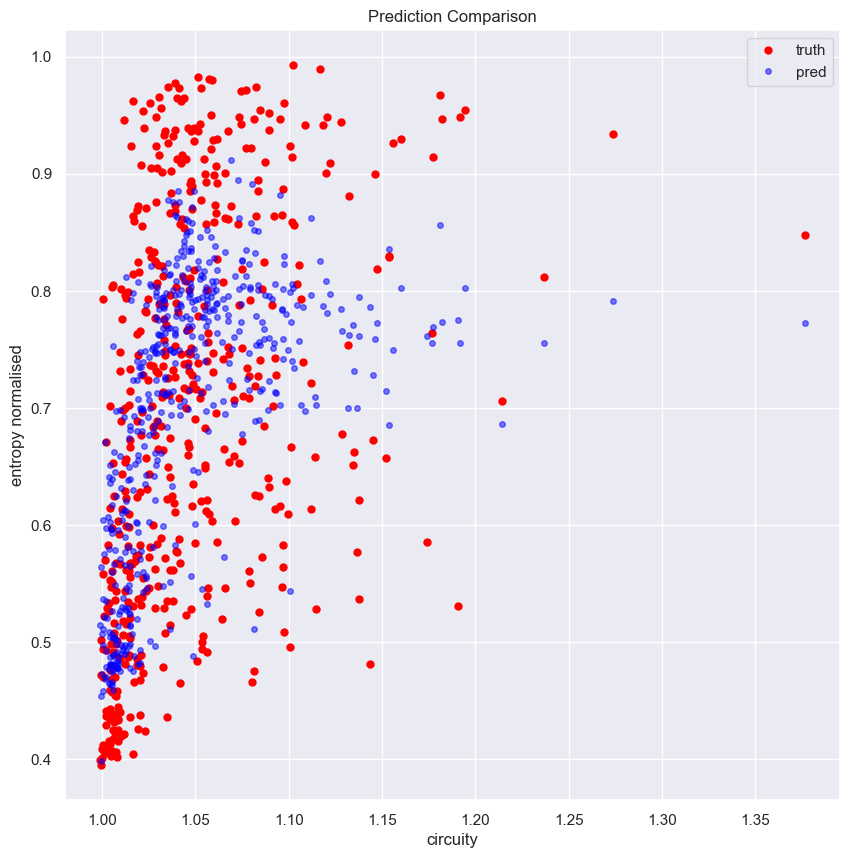

In [60]:
mean_edge_test = scalerX.inverse_transform(X_test)[:, feature_cols.index('mean_edge_length')]
circuity_test = scalerX.inverse_transform(X_test)[:, feature_cols.index('circuity')]

plot_comparison(mean_edge_test, y_pred, y_truth, "mean edge length", "entropy normalised")
plot_comparison(circuity_test, y_pred, y_truth, "circuity", "entropy normalised")


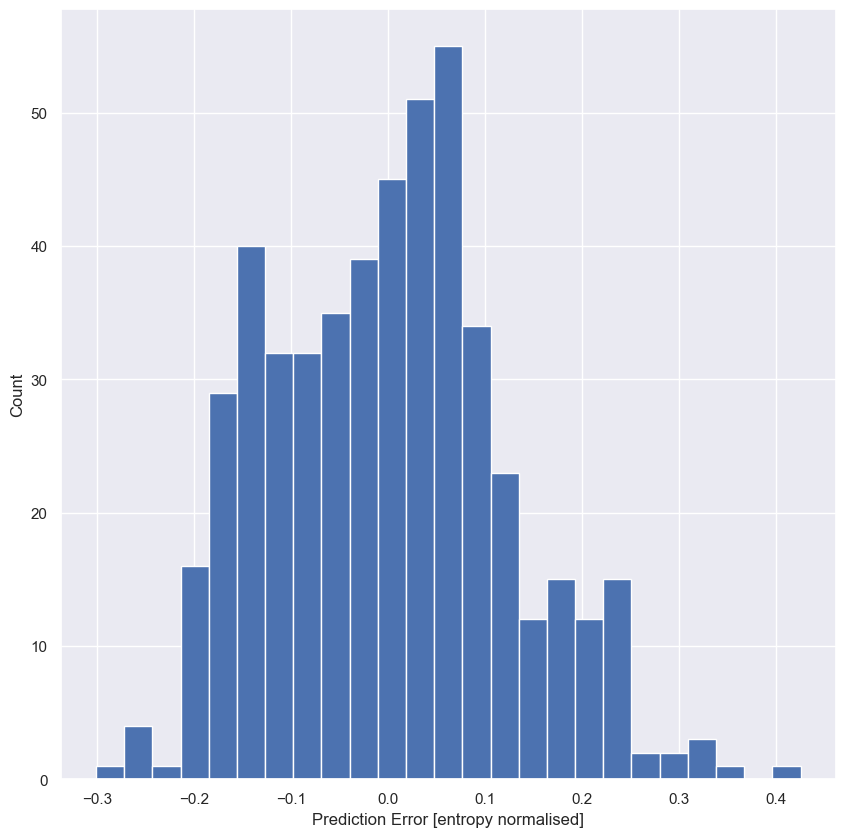

In [61]:
error = y_pred - y_truth
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [entropy normalised]')
_ = plt.ylabel('Count')


In [21]:
model.save('ANNregression_02.keras')

import pickle
pickle.dump(scalerX, open('scalerX.pkl', 'wb'))
pickle.dump(scalerY, open('scalerY.pkl', 'wb'))

print("Model and scalers saved!")


Model and scalers saved!
